# Atividades 2, 3 e 4 — GráficosEste notebook monta os gráficos pedidos para as atividades 2, 3 e 4, reaproveitando as tabelas já trabalhadas nas aulas 2 e 3, e a análise de população.A **Parte 2 (IDH)** está no fim do notebook, mas o arquivo de IDH ainda não foi enviado — veja a observação na seção correspondente.

In [ ]:
import pandas as pdimport matplotlib.pyplot as pltimport seaborn as sns

## Atividade 2 — Horas de afazeres domésticos (homens x mulheres, por região)Reconstruindo `indicador_1` a partir da *Tabela 1.1.1* (mesma limpeza da Aula 2).

In [1]:
path_horas = "Tabela 1.1.1.xls"bruto_1 = pd.read_excel(path_horas, engine="xlrd", header=None)indicador_1 = bruto_1.iloc[8:41].copy()indicador_1.columns = [    "uf_regiao",    "total",    "total_branca",    "total_preta_parda",    "homem_branca",    "homem_preta_parda",    "mulher_branca",    "mulher_preta_parda",]indicador_1 = indicador_1.reset_index(drop=True)for col in indicador_1.columns[1:]:    indicador_1[col] = pd.to_numeric(indicador_1[col], errors="coerce")indicador_1.head()

  uf_regiao      total  total_branca  total_preta_parda  homem_branca  \0    Brasil  16.985781     16.545930          17.333142     11.705136   1     Norte  16.187037     15.925246          16.256032     11.588653   2  Rondônia  17.014162     16.727733          17.101523     12.111127   3      Acre  13.606903     13.806929          13.541399     10.796120   4  Amazonas  16.807290     15.987545          16.995493     12.233043      homem_preta_parda  mulher_branca  mulher_preta_parda  0          11.746330      20.404106           22.037998  1          11.514646      19.295780           20.534188  2          12.544080      20.412887           21.061410  3           9.686983      16.130352           16.710754  4          12.822584      18.764969           20.716986  

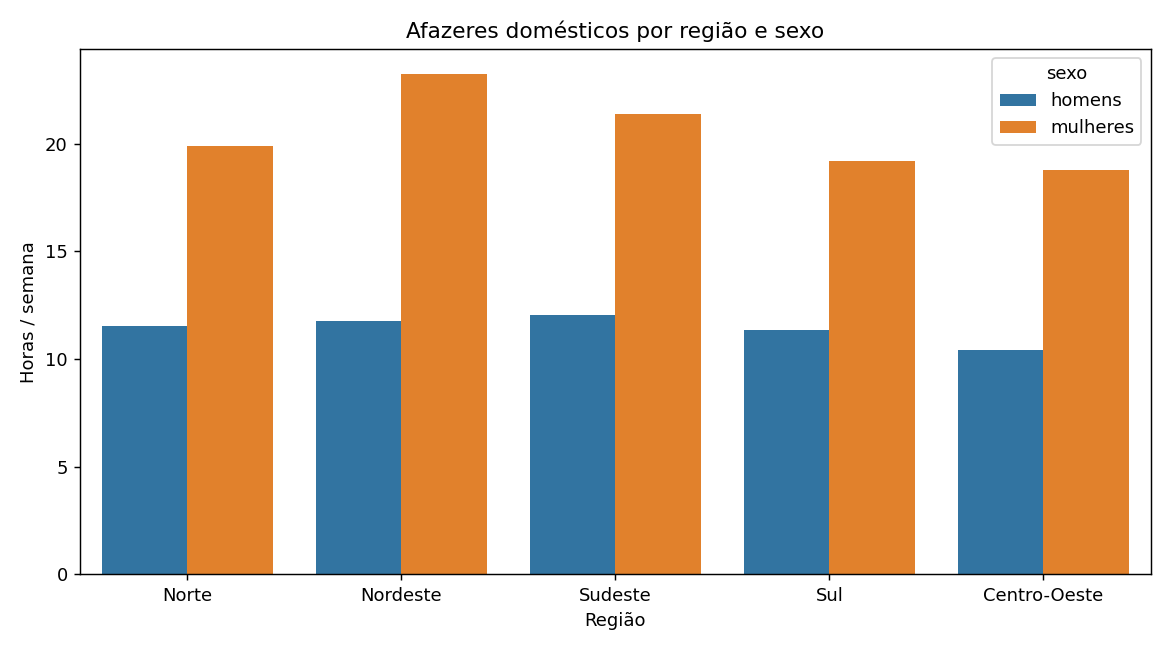

In [2]:
# Barras agrupadas: homens x mulheres por grande regiãoregioes = ["Norte", "Nordeste", "Sudeste", "Sul", "Centro-Oeste"]reg = indicador_1[indicador_1["uf_regiao"].isin(regioes)].copy()reg["homens"] = (reg["homem_branca"] + reg["homem_preta_parda"]) / 2reg["mulheres"] = (reg["mulher_branca"] + reg["mulher_preta_parda"]) / 2reg_long = reg.melt(    id_vars="uf_regiao",    value_vars=["homens", "mulheres"],    var_name="sexo",    value_name="horas",)fig, ax = plt.subplots(figsize=(9, 5))sns.barplot(data=reg_long, x="uf_regiao", y="horas", hue="sexo", ax=ax)ax.set_title("Afazeres domésticos por região e sexo")ax.set_xlabel("Região")ax.set_ylabel("Horas / semana")plt.tight_layout()plt.savefig("atividade2_afazeres_domesticos.png", dpi=150, bbox_inches="tight")plt.show()

Em todas as regiões as mulheres dedicam mais horas por semana aos afazeres domésticos do que os homens; a diferença é maior no Nordeste (~11,4 h a mais) e menor no Centro-Oeste (~8,3 h a mais).

## Atividade 3 — Formação acadêmica (homens x mulheres, por área)Reconstruindo `formacao_total`, `formacao_stem` e `formacao_saude` a partir da *Tabela 3 — Áreas gerais de formação na graduação*.

In [3]:
path = "Tabela_3_Areas_gerais_de_formacao_na_graduacao.xlsx"formacao_bruto = pd.read_excel(path, header=None)# Total geral (colunas 0 a 3)formacao_total = formacao_bruto.iloc[3:36, [0, 1, 2, 3]].copy()formacao_total.columns = ["uf_regiao", "total", "total_homens", "total_mulheres"]# Ciência, Tecnologia, Engenharias e Matemática — STEM (colunas 4 a 6)formacao_stem = formacao_bruto.iloc[3:36, [0, 4, 5, 6]].copy()formacao_stem.columns = ["uf_regiao", "total", "homens", "mulheres"]# Educação, Serviços pessoais, Saúde e Bem-estar (colunas 7 a 9)formacao_saude = formacao_bruto.iloc[3:36, [0, 7, 8, 9]].copy()formacao_saude.columns = ["uf_regiao", "total", "homens", "mulheres"]for tabela in (formacao_total, formacao_stem, formacao_saude):    for col in tabela.columns[1:]:        tabela[col] = pd.to_numeric(tabela[col], errors="coerce")formacao_total["percentual_mulheres"] = (    formacao_total["total_mulheres"] / formacao_total["total"] * 100).round(2)formacao_total.head()

  uf_regiao     total  total_homens  total_mulheres  percentual_mulheres3    Brasil  25854291      10478534        15375757                59.474     Norte   1525166        590558          934609                61.285  Nordeste   4748933       1744994         3003939                63.266   Sudeste  12828829       5391638         7437191                57.977       Sul   4338861       1768855         2570005                59.23

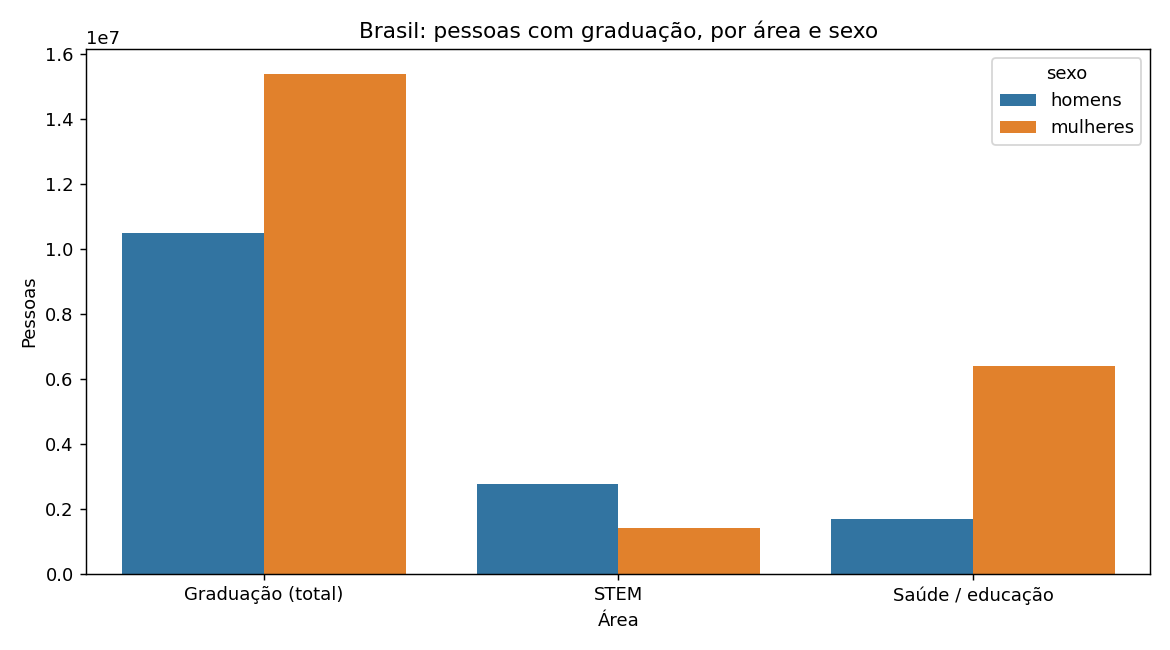

In [4]:
# Barras agrupadas: homens x mulheres no Brasil (três recortes)brasil = pd.DataFrame(    {        "area": ["Graduação (total)", "STEM", "Saúde / educação"],        "homens": [            formacao_total.loc[formacao_total["uf_regiao"] == "Brasil", "total_homens"].item(),            formacao_stem.loc[formacao_stem["uf_regiao"] == "Brasil", "homens"].item(),            formacao_saude.loc[formacao_saude["uf_regiao"] == "Brasil", "homens"].item(),        ],        "mulheres": [            formacao_total.loc[formacao_total["uf_regiao"] == "Brasil", "total_mulheres"].item(),            formacao_stem.loc[formacao_stem["uf_regiao"] == "Brasil", "mulheres"].item(),            formacao_saude.loc[formacao_saude["uf_regiao"] == "Brasil", "mulheres"].item(),        ],    })brasil_long = brasil.melt(id_vars="area", var_name="sexo", value_name="pessoas")fig, ax = plt.subplots(figsize=(9, 5))sns.barplot(data=brasil_long, x="area", y="pessoas", hue="sexo", ax=ax)ax.set_title("Brasil: pessoas com graduação, por área e sexo")ax.set_xlabel("Área")ax.set_ylabel("Pessoas")plt.tight_layout()plt.savefig("atividade3_formacao_academica.png", dpi=150, bbox_inches="tight")plt.show()

No total de graduados, mulheres são maioria (~59,5%). Mas o padrão se inverte em STEM: homens são quase o dobro das mulheres (2,75 milhões x 1,40 milhão). Em Saúde/Educação, o desequilíbrio é ainda maior no sentido oposto: mulheres são quase 4x os homens (6,4 milhões x 1,68 milhão).

## Atividade 4 — População 2022 por UFUsando a tabela `populacao_por_estado.csv` já gerada em `analise_populacao.ipynb`.

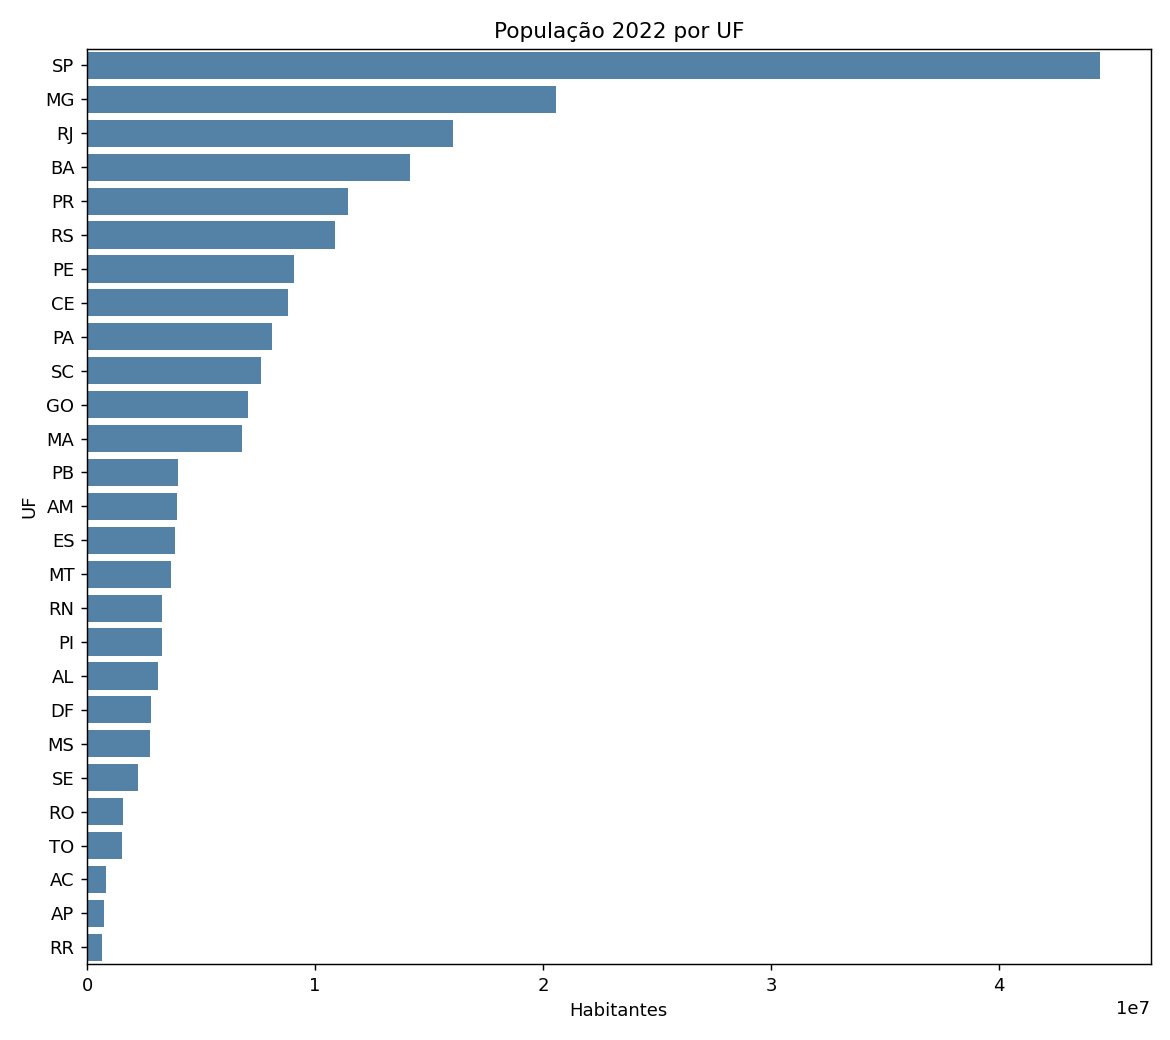

In [5]:
pop_estado = pd.read_csv("populacao_por_estado.csv", sep=";")# Barras: população 2022 por UFordem = pop_estado.sort_values("populacao_2022", ascending=False)fig, ax = plt.subplots(figsize=(9, 8))sns.barplot(data=ordem, y="UF", x="populacao_2022", ax=ax, color="steelblue")ax.set_title("População 2022 por UF")ax.set_xlabel("Habitantes")ax.set_ylabel("UF")plt.tight_layout()plt.savefig("atividade4_populacao_2022_por_uf.png", dpi=150, bbox_inches="tight")plt.show()

São Paulo lidera com folga (~44,4 milhões), seguido por Minas Gerais (~20,6 milhões) e Rio de Janeiro (~16,1 milhões). Note que o eixo usa `populacao_2022`, não `"2022"` como no roteiro — esse é o nome real da coluna no CSV gerado.

## Parte 2 — IDH⚠️ **Arquivo em falta:** nenhum CSV de IDH foi enviado junto com os outros arquivos, então esta parte não pôde ser executada aqui. Assim que você tiver o arquivo (algo como `ATLAS_IDH.csv`, com colunas de UF/estado e uma coluna por ano), envie-o e eu completo esta seção com o código já testado e o gráfico pronto.O código abaixo é o roteiro da atividade, pronto para rodar assim que o caminho do arquivo for ajustado:

In [ ]:
# 1. Abrir um CSV com ";" e vírgula decimaldf = pd.read_csv("CAMINHO_DO_ARQUIVO_IDH.csv", sep=";", decimal=",")# 2. Limpar colunas vaziasdf = df.dropna(axis=1, how="all")# 3. Passar do formato largo para o formato longo (melt)anos = [c for c in df.columns if str(c).isdigit()]variaveis = [c for c in df.columns if c not in anos]df_longo = df.melt(    id_vars=variaveis,    value_vars=anos,    var_name="Ano",    value_name="IDH",)# 4. Evolução do IDH de cada estadofig, ax = plt.subplots(figsize=(12, 7))for sigla, grupo in df_longo.groupby("Sigla"):    grupo = grupo.sort_values("Ano")    ax.plot(grupo["Ano"], grupo["IDH"], marker="o", markersize=3, linewidth=1.5, label=sigla)ax.set_title("Evolução do IDH por estado (1991–2024)")ax.set_xlabel("Ano")ax.set_ylabel("IDH")ax.set_ylim(0.3, 0.9)ax.legend(ncol=3, bbox_to_anchor=(1.02, 1), loc="upper left", title="UF")fig.tight_layout()plt.show()

In [ ]:
# 5. IDH de Minas Geraismg = df_longo[df_longo["Sigla"] == "MG"].sort_values("Ano")fig, ax = plt.subplots(figsize=(9, 5))ax.plot(mg["Ano"], mg["IDH"], marker="o", color="firebrick")ax.set_title("Evolução do IDH — Minas Gerais")ax.set_xlabel("Ano")ax.set_ylabel("IDH")plt.tight_layout()plt.show()